In [1]:
import os
import time
import datetime
import json
import gc
from numba import jit

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm_notebook

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn import metrics

from itertools import product

# import altair as alt


import altair as alt
alt.renderers.enable('html')  # hoặc 'default', 'notebook' tùy môi trường

    

def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                c_prec = df[col].apply(lambda x: np.finfo(x).precision).max()
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max and c_prec == np.finfo(np.float32).precision:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df
    

@jit
def fast_auc(y_true, y_prob):
    """
    fast roc_auc computation: https://www.kaggle.com/c/microsoft-malware-prediction/discussion/76013
    """
    y_true = np.asarray(y_true)
    y_true = y_true[np.argsort(y_prob)]
    nfalse = 0
    auc = 0
    n = len(y_true)
    for i in range(n):
        y_i = y_true[i]
        nfalse += (1 - y_i)
        auc += y_i * nfalse
    auc /= (nfalse * (n - nfalse))
    return auc


def eval_auc(y_true, y_pred):
    """
    Fast auc eval function for lgb.
    """
    return 'auc', fast_auc(y_true, y_pred), True


def group_mean_log_mae(y_true, y_pred, types, floor=1e-9):
    """
    Fast metric computation for this competition: https://www.kaggle.com/c/champs-scalar-coupling
    Code is from this kernel: https://www.kaggle.com/uberkinder/efficient-metric
    """
    maes = (y_true-y_pred).abs().groupby(types).mean()
    return np.log(maes.map(lambda x: max(x, floor))).mean()
    

def train_model_regression(X, X_test, y, params, folds=None, model_type='lgb', eval_metric='mae', columns=None, plot_feature_importance=False, model=None,
                               verbose=10000, early_stopping_rounds=200, n_estimators=50000, splits=None, n_folds=3):
    """
    A function to train a variety of regression models.
    Returns dictionary with oof predictions, test predictions, scores and, if necessary, feature importances.
    
    :params: X - training data, can be pd.DataFrame or np.ndarray (after normalizing)
    :params: X_test - test data, can be pd.DataFrame or np.ndarray (after normalizing)
    :params: y - target
    :params: folds - folds to split data
    :params: model_type - type of model to use
    :params: eval_metric - metric to use
    :params: columns - columns to use. If None - use all columns
    :params: plot_feature_importance - whether to plot feature importance of LGB
    :params: model - sklearn model, works only for "sklearn" model type
    
    """
    columns = X.columns if columns is None else columns
    X_test = X_test[columns]
    splits = folds.split(X) if splits is None else splits
    n_splits = folds.n_splits if splits is None else n_folds
    
    # to set up scoring parameters
    metrics_dict = {'mae': {'lgb_metric_name': 'mae',
                        'catboost_metric_name': 'MAE',
                        'sklearn_scoring_function': metrics.mean_absolute_error},
                    'group_mae': {'lgb_metric_name': 'mae',
                        'catboost_metric_name': 'MAE',
                        'scoring_function': group_mean_log_mae},
                    'mse': {'lgb_metric_name': 'mse',
                        'catboost_metric_name': 'MSE',
                        'sklearn_scoring_function': metrics.mean_squared_error}
                    }

    
    result_dict = {}
    
    # out-of-fold predictions on train data
    oof = np.zeros(len(X))
    
    # averaged predictions on train data
    prediction = np.zeros(len(X_test))
    
    # list of scores on folds
    scores = []
    feature_importance = pd.DataFrame()
    
    # split and train on folds
    for fold_n, (train_index, valid_index) in enumerate(splits):
        if verbose:
            print(f'Fold {fold_n + 1} started at {time.ctime()}')
        if type(X) == np.ndarray:
            X_train, X_valid = X[columns][train_index], X[columns][valid_index]
            y_train, y_valid = y[train_index], y[valid_index]
        else:
            X_train, X_valid = X[columns].iloc[train_index], X[columns].iloc[valid_index]
            y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
            
        if model_type == 'lgb':
            model = lgb.LGBMRegressor(**params, n_estimators = n_estimators, n_jobs = -1)
            model.fit(X_train, y_train, 
                    eval_set=[(X_train, y_train), (X_valid, y_valid)], eval_metric=metrics_dict[eval_metric]['lgb_metric_name'],
                    verbose=verbose, early_stopping_rounds=early_stopping_rounds)
            
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test, num_iteration=model.best_iteration_)
            
        if model_type == 'xgb':
            train_data = xgb.DMatrix(data=X_train, label=y_train, feature_names=X.columns)
            valid_data = xgb.DMatrix(data=X_valid, label=y_valid, feature_names=X.columns)

            watchlist = [(train_data, 'train'), (valid_data, 'valid_data')]
            model = xgb.train(dtrain=train_data, num_boost_round=20000, evals=watchlist, early_stopping_rounds=200, verbose_eval=verbose, params=params)
            y_pred_valid = model.predict(xgb.DMatrix(X_valid, feature_names=X.columns), ntree_limit=model.best_ntree_limit)
            y_pred = model.predict(xgb.DMatrix(X_test, feature_names=X.columns), ntree_limit=model.best_ntree_limit)
        
        if model_type == 'sklearn':
            model = model
            model.fit(X_train, y_train)
            
            y_pred_valid = model.predict(X_valid).reshape(-1,)
            score = metrics_dict[eval_metric]['sklearn_scoring_function'](y_valid, y_pred_valid)
            print(f'Fold {fold_n}. {eval_metric}: {score:.4f}.')
            print('')
            
            y_pred = model.predict(X_test).reshape(-1,)
        
        if model_type == 'cat':
            model = CatBoostRegressor(iterations=20000,  eval_metric=metrics_dict[eval_metric]['catboost_metric_name'], **params,
                                      loss_function=metrics_dict[eval_metric]['catboost_metric_name'])
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=[], use_best_model=True, verbose=False)

            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)
        
        oof[valid_index] = y_pred_valid.reshape(-1,)
        if eval_metric != 'group_mae':
            scores.append(metrics_dict[eval_metric]['sklearn_scoring_function'](y_valid, y_pred_valid))
        else:
            scores.append(metrics_dict[eval_metric]['scoring_function'](y_valid, y_pred_valid, X_valid['type']))

        prediction += y_pred    
        
        if model_type == 'lgb' and plot_feature_importance:
            # feature importance
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    prediction /= n_splits
    print('CV mean score: {0:.4f}, std: {1:.4f}.'.format(np.mean(scores), np.std(scores)))
    
    result_dict['oof'] = oof
    result_dict['prediction'] = prediction
    result_dict['scores'] = scores
    
    if model_type == 'lgb':
        if plot_feature_importance:
            feature_importance["importance"] /= n_splits
            cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
                by="importance", ascending=False)[:50].index

            best_features = feature_importance.loc[feature_importance.feature.isin(cols)]

            plt.figure(figsize=(16, 12));
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False));
            plt.title('LGB Features (avg over folds)');
            
            result_dict['feature_importance'] = feature_importance
        
    return result_dict
    



def train_model_classification(X, X_test, y, params, folds, model_type='lgb', eval_metric='auc', columns=None, plot_feature_importance=False, model=None,
                               verbose=10000, early_stopping_rounds=200, n_estimators=50000, splits=None, n_folds=3, averaging='usual', n_jobs=-1):
    """
    A function to train a variety of classification models.
    Returns dictionary with oof predictions, test predictions, scores and, if necessary, feature importances.
    """
    columns = X.columns if columns is None else columns
    n_splits = folds.n_splits if splits is None else n_folds
    X_test = X_test[columns]
    
    # to set up scoring parameters
    metrics_dict = {'auc': {'lgb_metric_name': 'auc',
                            'catboost_metric_name': 'AUC',
                            'sklearn_scoring_function': metrics.roc_auc_score},
                    }
    
    result_dict = {}
    if averaging == 'usual':
        # out-of-fold predictions on train data
        oof = np.zeros((len(X), 1))

        # averaged predictions on train data
        prediction = np.zeros((len(X_test), 1))
        
    elif averaging == 'rank':
        # out-of-fold predictions on train data
        oof = np.zeros((len(X), 1))

        # averaged predictions on train data
        prediction = np.zeros((len(X_test), 1))

    # list of scores on folds
    scores = []
    feature_importance = pd.DataFrame()
    
    # split and train on folds
    for fold_n, (train_index, valid_index) in enumerate(folds.split(X)):
        print(f'Fold {fold_n + 1} started at {time.ctime()}')
        if type(X) == np.ndarray:
            X_train, X_valid = X[columns][train_index], X[columns][valid_index]
            y_train, y_valid = y[train_index], y[valid_index]
        else:
            X_train, X_valid = X[columns].iloc[train_index], X[columns].iloc[valid_index]
            y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
            
        if model_type == 'lgb':
            model = lgb.LGBMClassifier(**params, n_estimators=n_estimators, n_jobs=n_jobs)
            model.fit(X_train, y_train, 
                      eval_set=[(X_train, y_train), (X_valid, y_valid)], eval_metric=metrics_dict[eval_metric]['lgb_metric_name'])
            
            y_pred_valid = model.predict_proba(X_valid)[:, 1]
            y_pred = model.predict_proba(X_test, num_iteration=model.best_iteration_)[:, 1]
        
        if model_type == 'xgb':
            train_data = xgb.DMatrix(data=X_train, label=y_train, feature_names=X.columns)
            valid_data = xgb.DMatrix(data=X_valid, label=y_valid, feature_names=X.columns)

            watchlist = [(train_data, 'train'), (valid_data, 'valid_data')]
            model = xgb.train(dtrain=train_data, num_boost_round=n_estimators, evals=watchlist, early_stopping_rounds=early_stopping_rounds, verbose_eval=verbose, params=params)
            y_pred_valid = model.predict(xgb.DMatrix(X_valid, feature_names=X.columns), ntree_limit=model.best_ntree_limit)
            y_pred = model.predict(xgb.DMatrix(X_test, feature_names=X.columns), ntree_limit=model.best_ntree_limit)
        
        if model_type == 'sklearn':
            model = model
            model.fit(X_train, y_train)
            
            y_pred_valid = model.predict(X_valid).reshape(-1,)
            score = metrics_dict[eval_metric]['sklearn_scoring_function'](y_valid, y_pred_valid)
            print(f'Fold {fold_n}. {eval_metric}: {score:.4f}.')
            print('')
            
            y_pred = model.predict_proba(X_test)
        
        if model_type == 'cat':
            model = CatBoostClassifier(iterations=n_estimators, eval_metric=metrics_dict[eval_metric]['catboost_metric_name'], **params,
                                      loss_function=Logloss)
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=[], use_best_model=True, verbose=False)

            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)
        
        if model_type == 'voting':
            # Create the voting classifier with LGB, RandomForest, Logistic Regression
            model_lgb = lgb.LGBMClassifier(**params, n_estimators=n_estimators, n_jobs=n_jobs)
            model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
            model_lr = LogisticRegression(max_iter=1000, random_state=42)

            voting_clf = VotingClassifier(
                estimators=[('lgb', model_lgb), ('rf', model_rf), ('lr', model_lr)],
                voting='soft'  # Use 'soft' voting to take the probability into account
            )

            # Train VotingClassifier
            voting_clf.fit(X_train, y_train)
            
            # Predict with VotingClassifier
            y_pred_valid = voting_clf.predict_proba(X_valid)[:, 1]
            y_pred = voting_clf.predict_proba(X_test)[:, 1]

        if averaging == 'usual':
            oof[valid_index] = y_pred_valid.reshape(-1, 1)
            scores.append(metrics_dict[eval_metric]['sklearn_scoring_function'](y_valid, y_pred_valid))
            
            prediction += y_pred.reshape(-1, 1)

        elif averaging == 'rank':
            oof[valid_index] = y_pred_valid.reshape(-1, 1)
            scores.append(metrics_dict[eval_metric]['sklearn_scoring_function'](y_valid, y_pred_valid))
            prediction += pd.Series(y_pred).rank().values.reshape(-1, 1)        
        
        if model_type == 'lgb' and plot_feature_importance:
            # feature importance
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    prediction /= n_splits
    
    print('CV mean score: {0:.4f}, std: {1:.4f}.'.format(np.mean(scores), np.std(scores)))
    
    result_dict['oof'] = oof
    result_dict['prediction'] = prediction
    result_dict['scores'] = scores
    
    if model_type == 'lgb':
        if plot_feature_importance:
            feature_importance["importance"] /= n_splits
            cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
                by="importance", ascending=False)[:50].index

            best_features = feature_importance.loc[feature_importance.feature.isin(cols)]

            plt.figure(figsize=(16, 12));
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False));
            plt.title('LGB Features (avg over folds)');
            
            result_dict['feature_importance'] = feature_importance
            result_dict['top_columns'] = cols
        
    return result_dict





In [2]:
folder_path = '../input/ieee-fraud-detection/'
train_identity = pd.read_csv(f'{folder_path}train_identity.csv')
train_transaction = pd.read_csv(f'{folder_path}train_transaction.csv')
test_identity = pd.read_csv(f'{folder_path}test_identity.csv')
test_transaction = pd.read_csv(f'{folder_path}test_transaction.csv')
sub = pd.read_csv(f'{folder_path}sample_submission.csv')
# let's combine the data and work with the whole dataset
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
test.columns = test.columns.str.replace('-','_')


In [3]:
print(f'Train dataset has {train.shape[0]} rows and {train.shape[1]} columns.')
print(f'Test dataset has {test.shape[0]} rows and {test.shape[1]} columns.')
train_transaction.head(),train_identity.head()

Train dataset has 590540 rows and 434 columns.
Test dataset has 506691 rows and 433 columns.


(   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
 0        2987000        0          86400            68.5         W  13926   
 1        2987001        0          86401            29.0         W   2755   
 2        2987002        0          86469            59.0         W   4663   
 3        2987003        0          86499            50.0         W  18132   
 4        2987004        0          86506            50.0         H   4497   
 
    card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
 0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
 4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   
 
   V336  V337  V338  V339  
 0  NaN   NaN   NaN   NaN  
 1  

In [4]:
del train_identity, train_transaction, test_identity, test_transaction

In [5]:
print(f'There are {train.isnull().any().sum()} columns in train dataset with missing values.')

There are 414 columns in train dataset with missing values.


In [6]:
one_value_cols = [col for col in train.columns if train[col].nunique() <= 1]
one_value_cols_test = [col for col in test.columns if test[col].nunique() <= 1]
one_value_cols == one_value_cols_test

False

In [7]:
print(f'There are {len(one_value_cols)} columns in train dataset with one unique value.')
print(f'There are {len(one_value_cols_test)} columns in test dataset with one unique value.')

There are 0 columns in train dataset with one unique value.
There are 1 columns in test dataset with one unique value.


Text(0.5, 1.0, 'Distribution of id_01 variable')

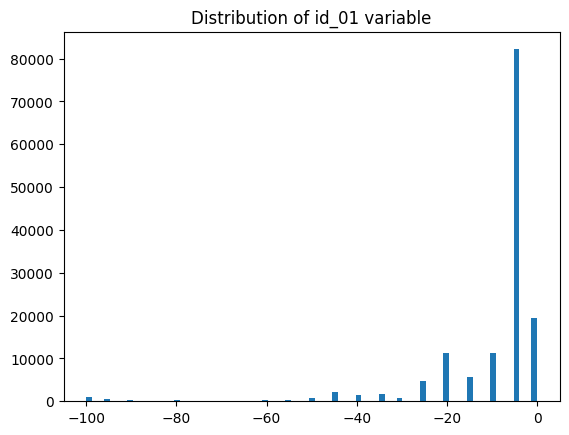

In [8]:
plt.hist(train['id_01'], bins=77)
plt.title('Distribution of id_01 variable')

In [9]:
train['id_03'].value_counts(dropna=False, normalize=True).head()
train['id_11'].value_counts(dropna=False, normalize=True).head()

id_11
NaN           0.761273
100.000000    0.225492
95.080002     0.002085
95.160004     0.001277
97.120003     0.000745
Name: proportion, dtype: float64

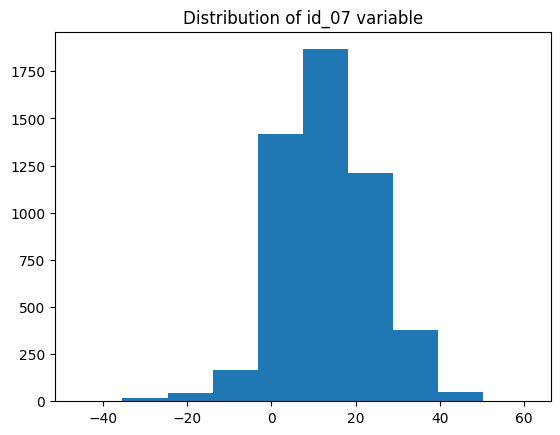

In [10]:
plt.hist(train['id_07']);
plt.title('Distribution of id_07 variable');

In [11]:
import matplotlib.pyplot as plt

def plot_value_counts(df, column, top=None):
    """
    Vẽ biểu đồ số lượng từng giá trị trong một cột.
    
    df: pandas DataFrame
    column: tên cột
    top: chỉ lấy top N giá trị (nếu None → lấy tất cả)
    """
    # Lấy count
    vc = df[column].value_counts(dropna=False)
    
    # Nếu muốn chỉ lấy top N
    if top is not None:
        vc = vc.head(top)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    vc.plot(kind='bar', color='skyblue')
    
    # Tiêu đề & label
    plt.title(f'Counts of {column}', fontsize=16)
    plt.ylabel('Count', fontsize=14)
    plt.xlabel(column, fontsize=14)
    
    # Xoay nhãn để dễ đọc
    plt.xticks(rotation=45, ha='right')
    
    # Hiển thị số trên đầu cột
    for i, v in enumerate(vc.values):
        plt.text(i, v + max(vc.values)*0.01, str(v), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()




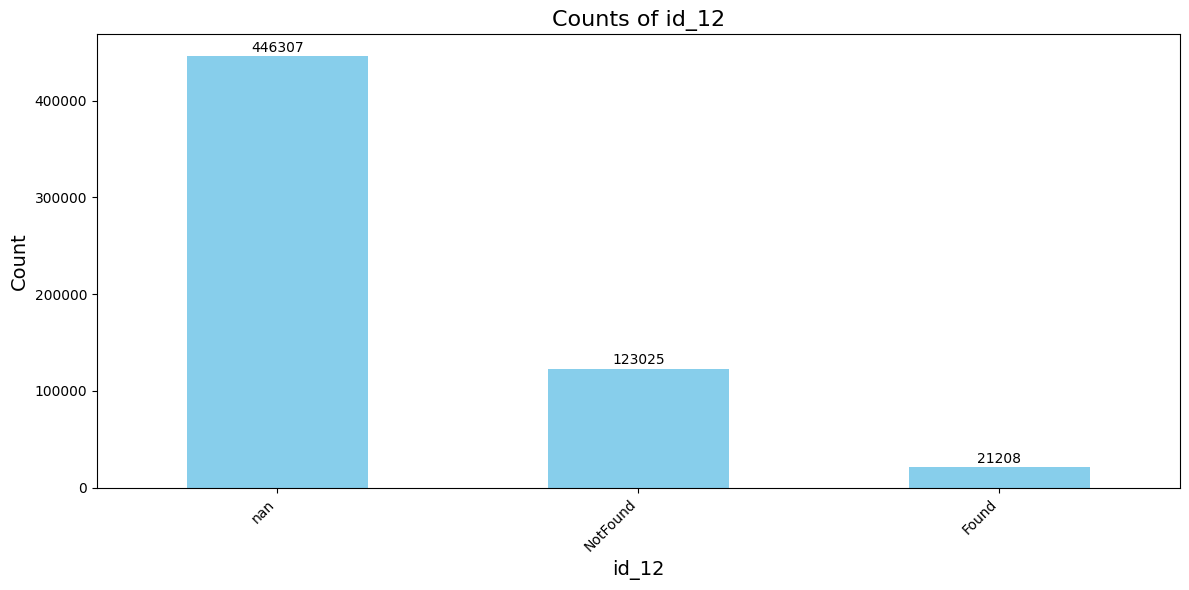

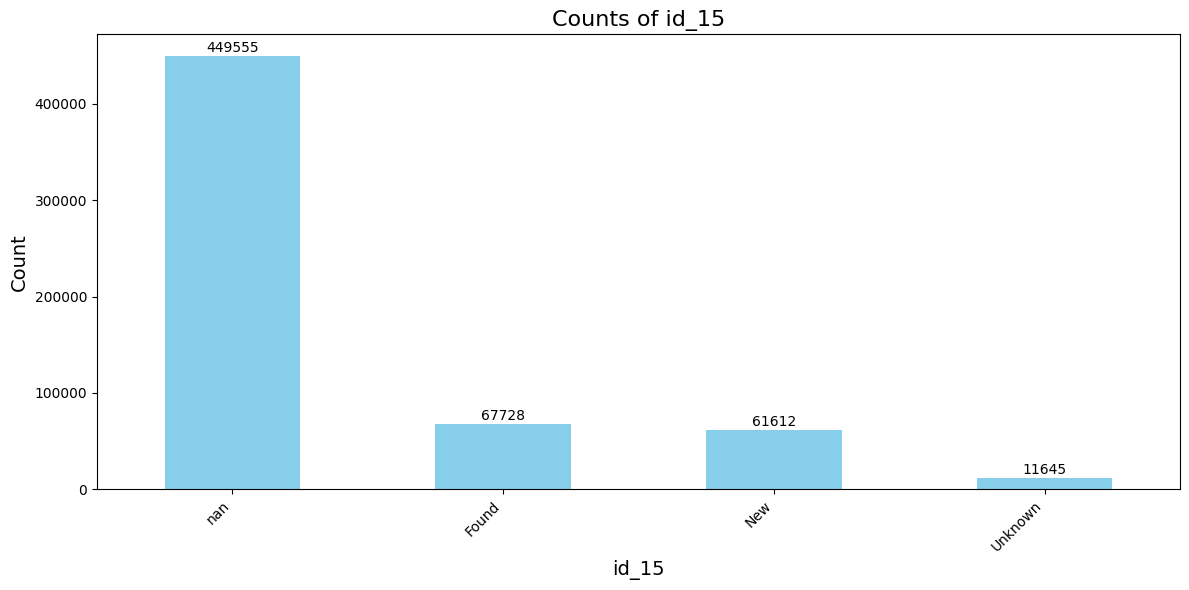

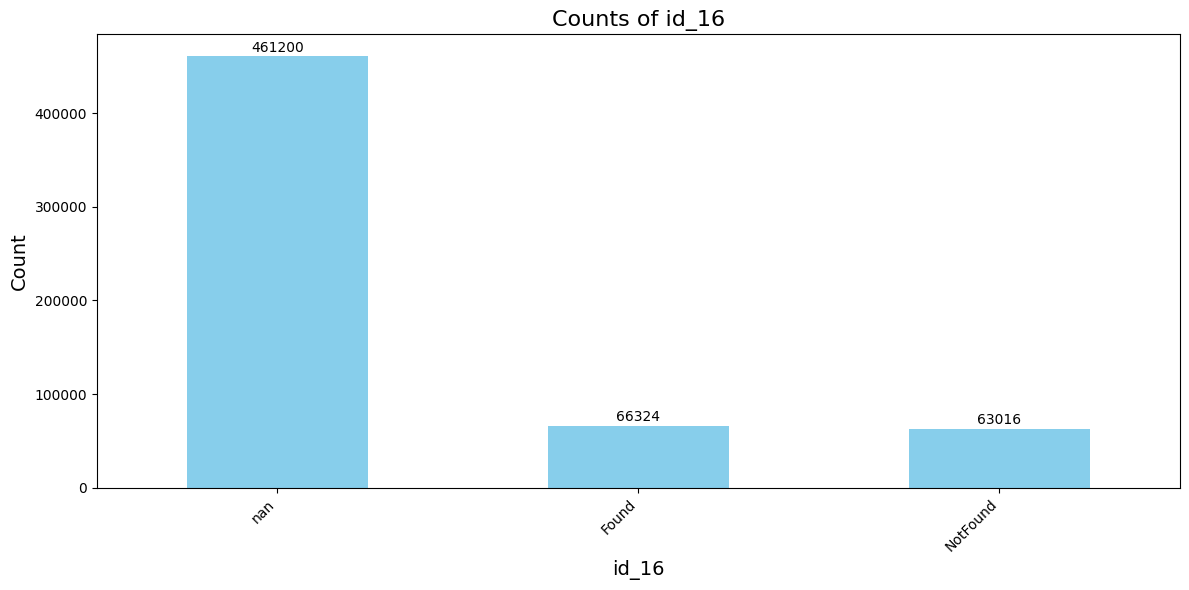

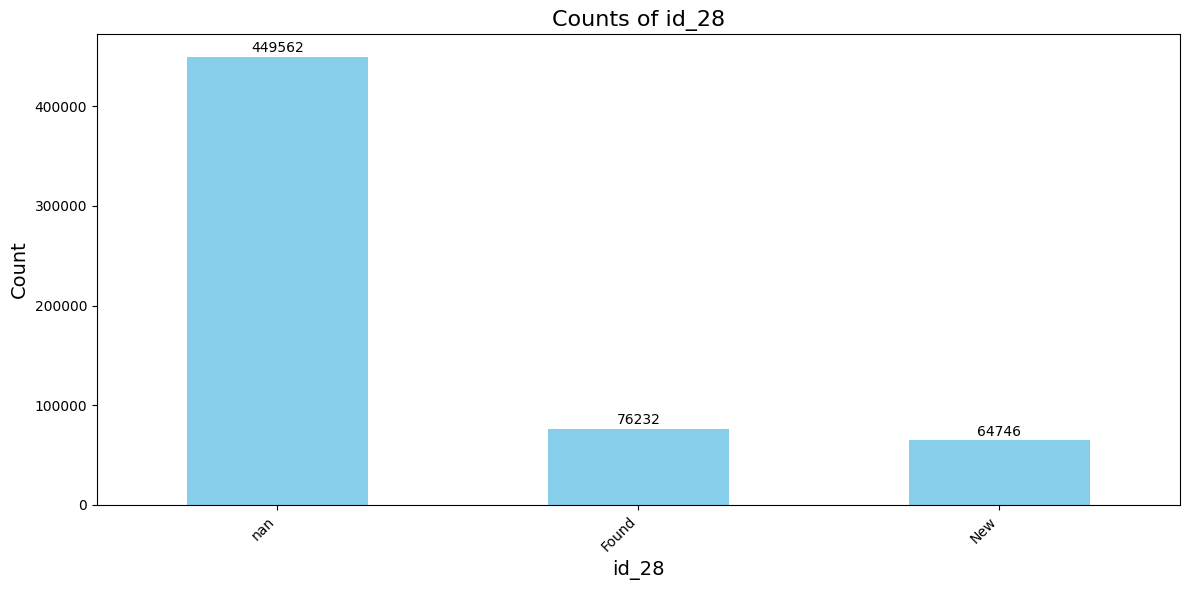

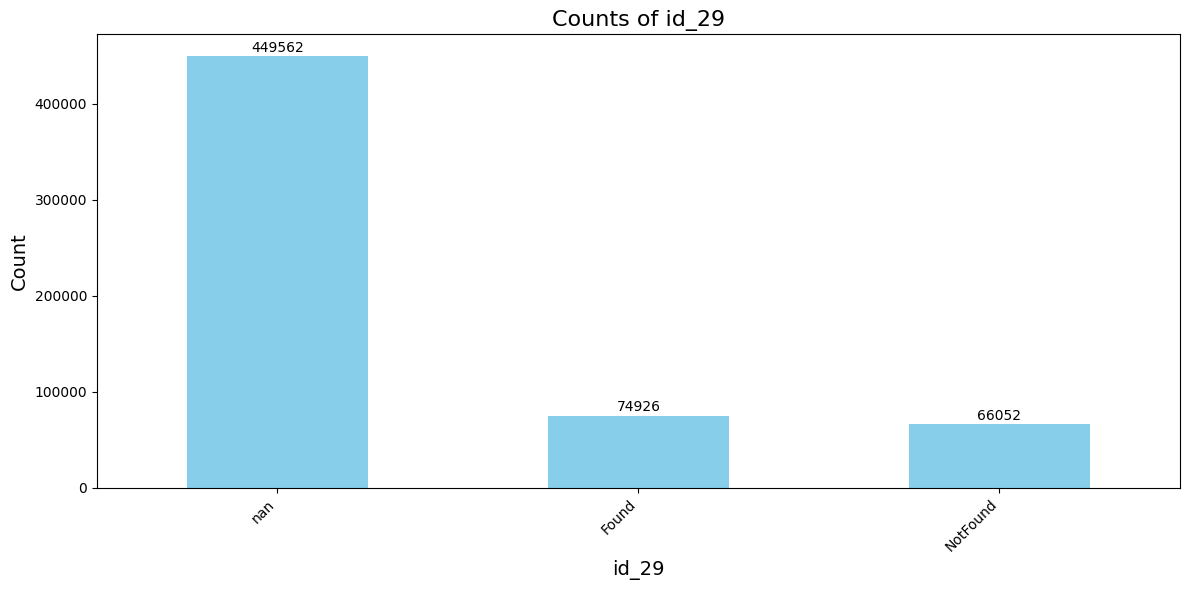

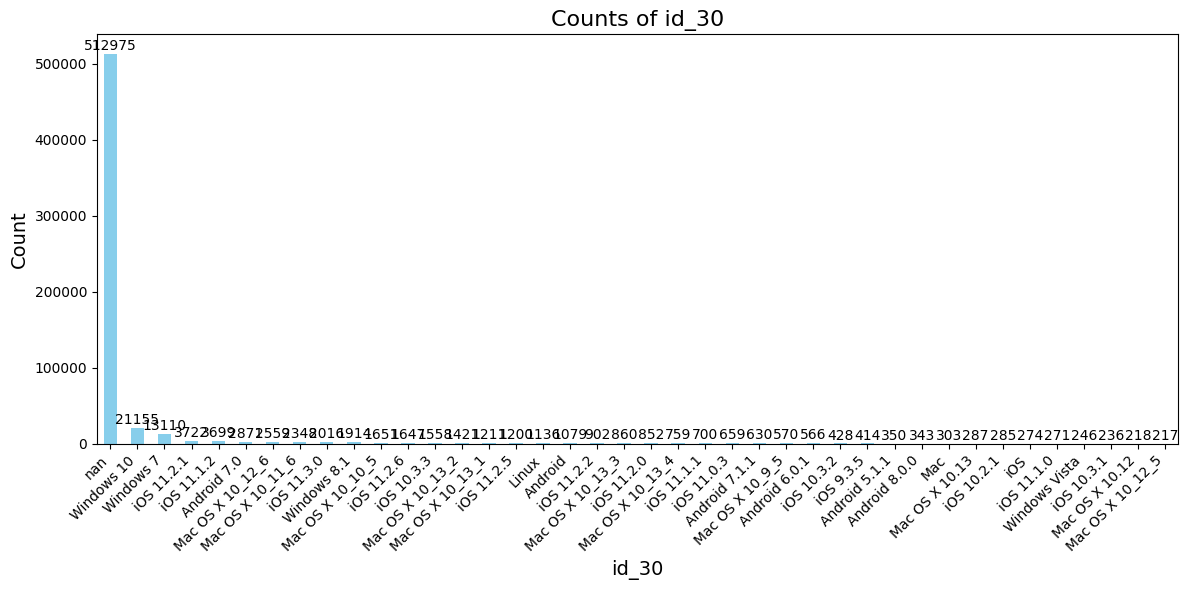

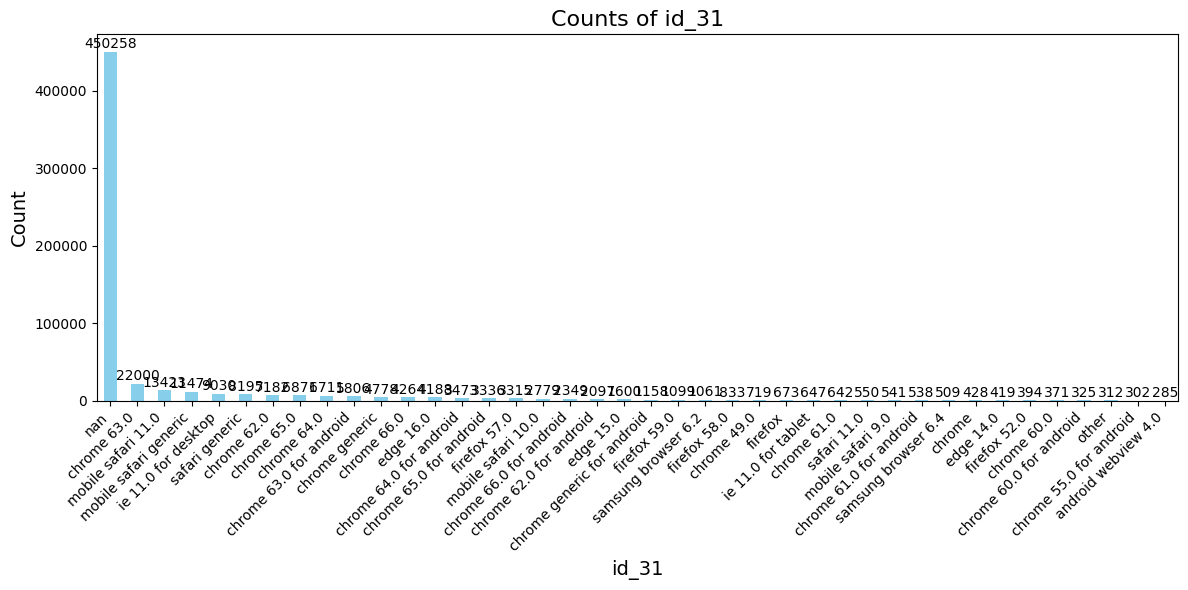

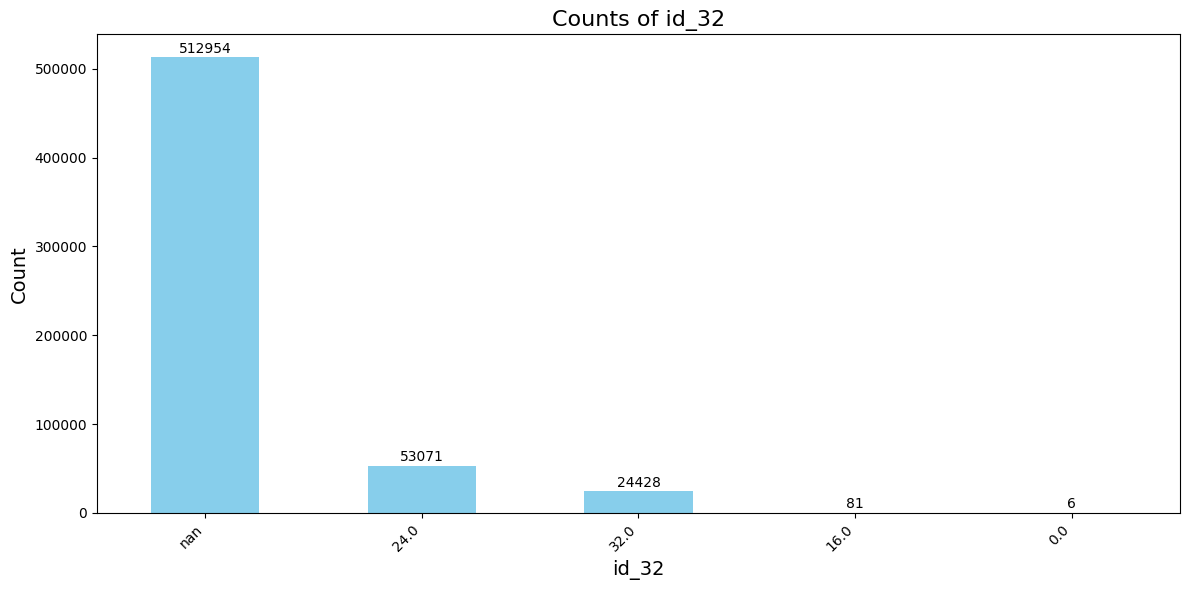

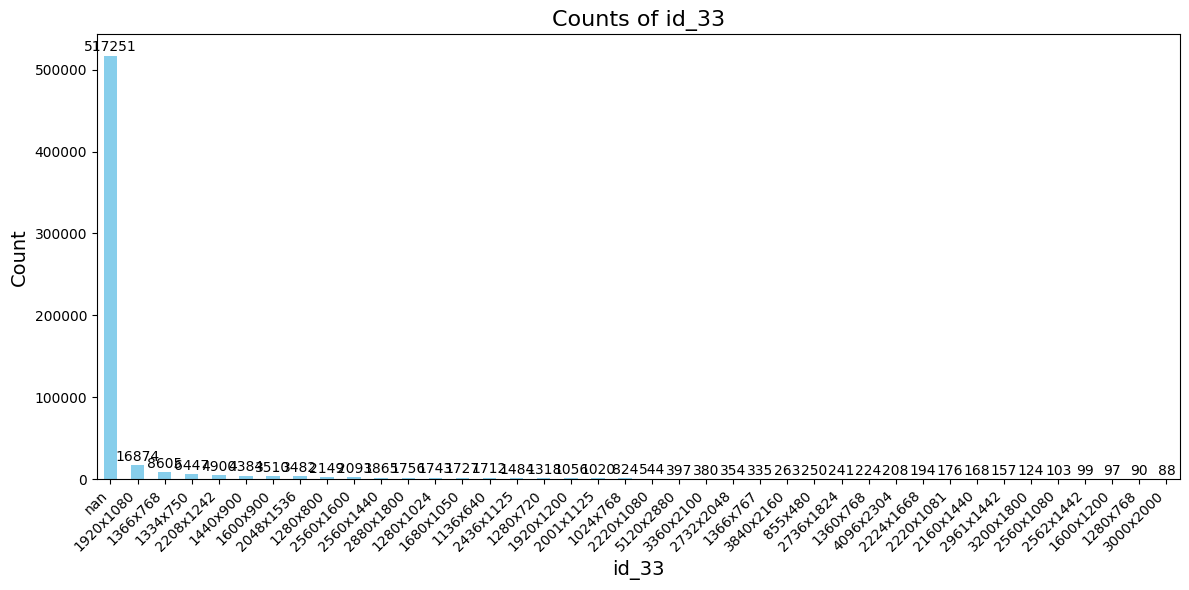

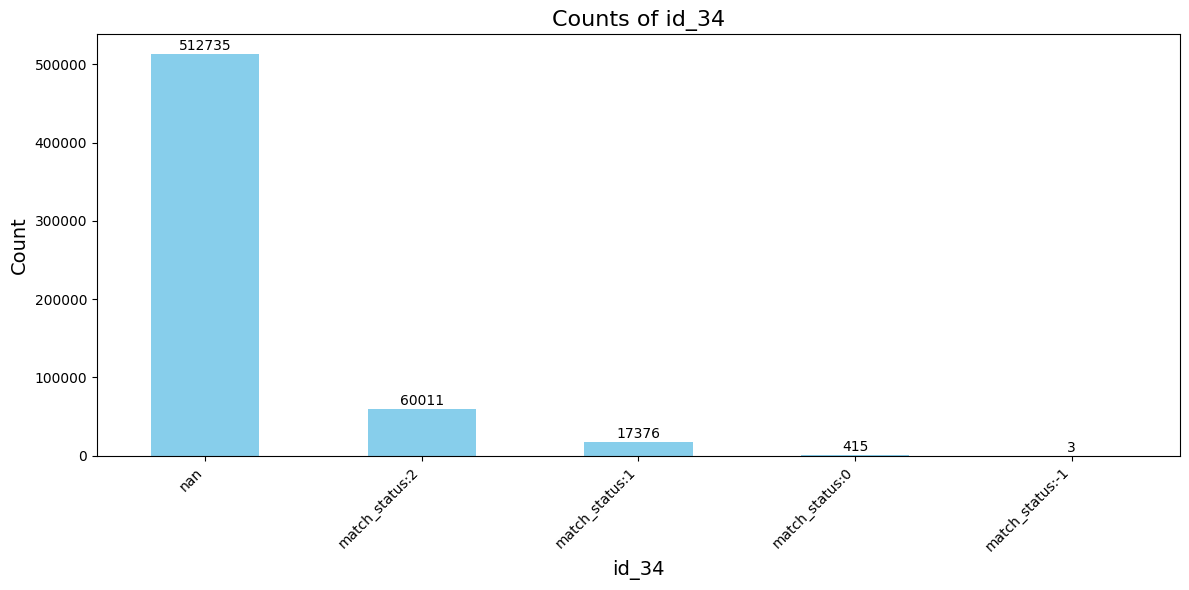

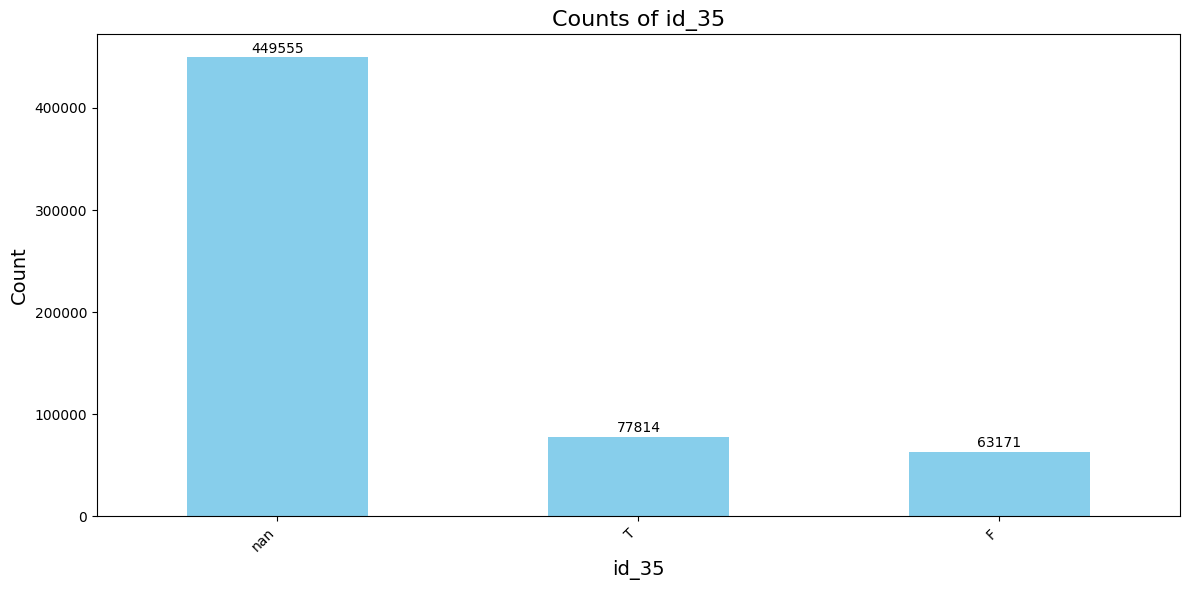

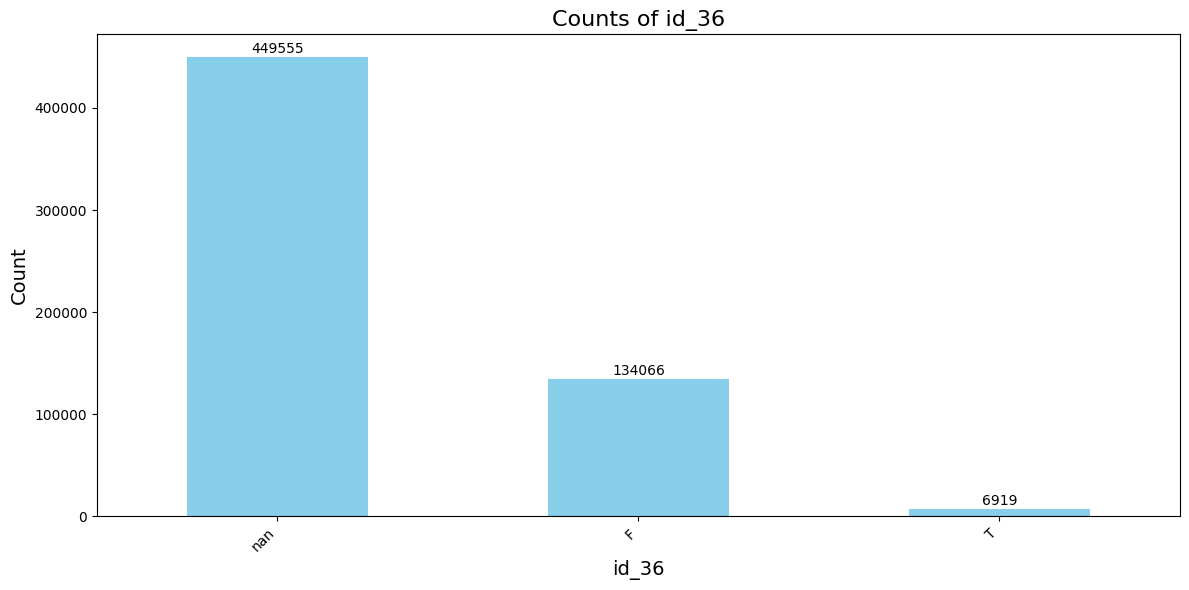

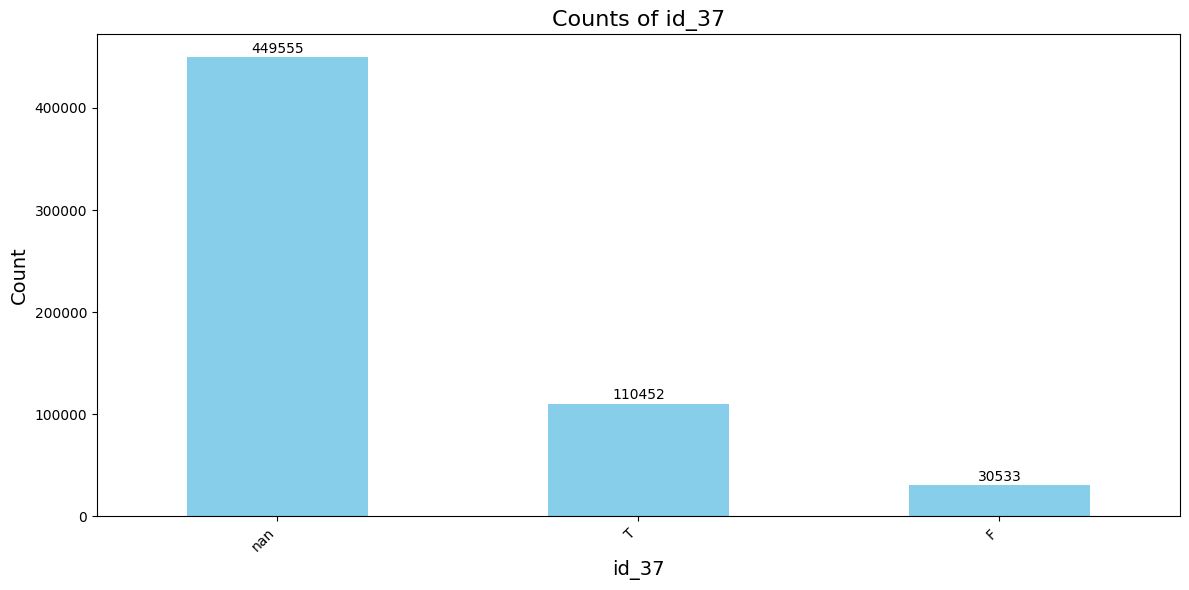

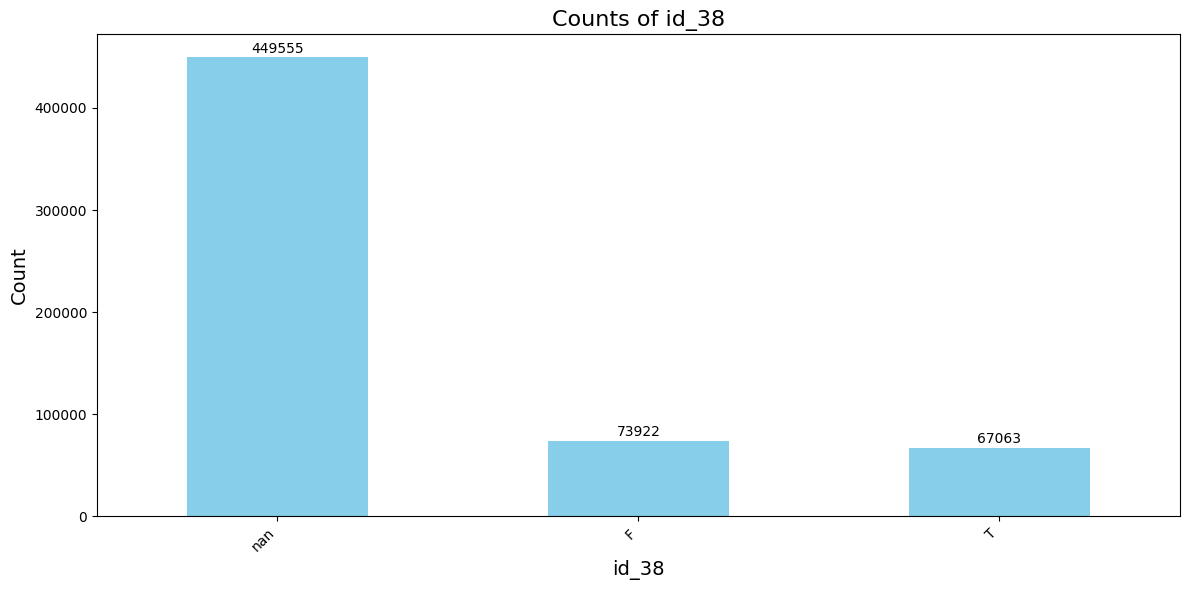

In [12]:
columns_to_plot = [
    'id_12', 'id_15', 'id_16',
    'id_28', 'id_29', 'id_30', 'id_31',
    'id_32', 'id_33', 'id_34', 'id_35',
    'id_36', 'id_37', 'id_38'
]

for col in columns_to_plot:
    plot_value_counts(train, col,40)

Text(0.5, 1.0, 'Distribution of transactiond dates')

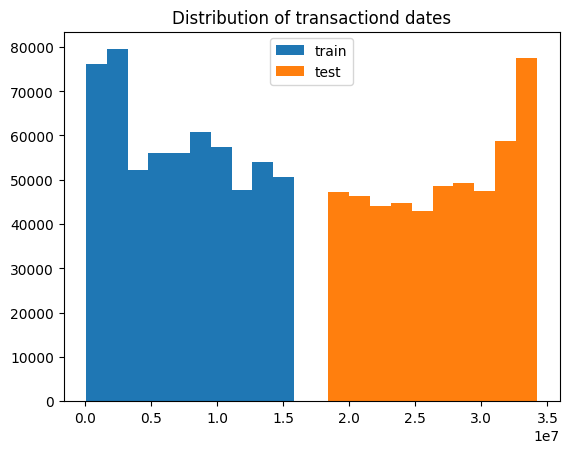

In [13]:
plt.hist(train['TransactionDT'], label='train')
plt.hist(test['TransactionDT'], label='test')
plt.legend()
plt.title('Distribution of transactiond dates')


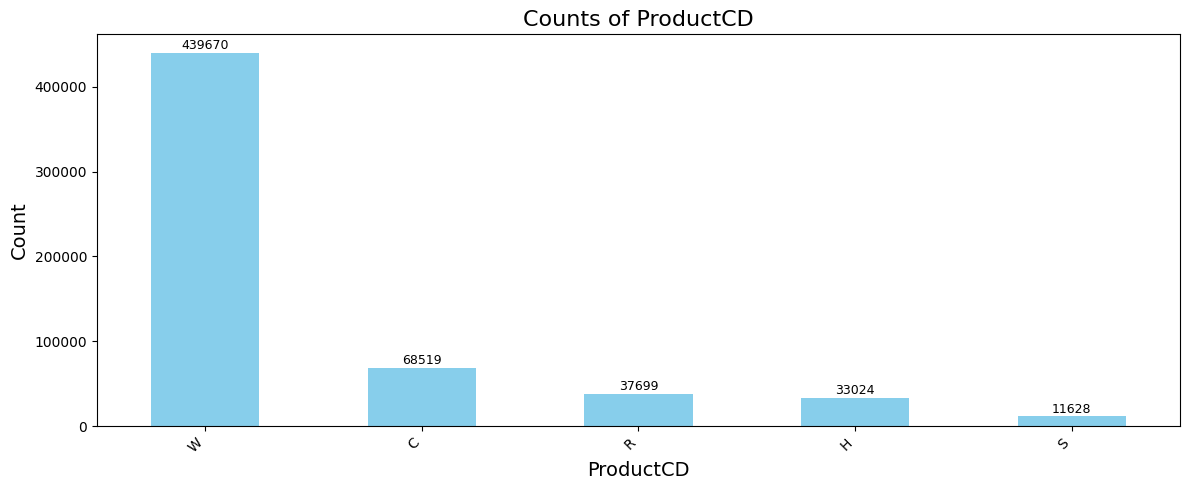

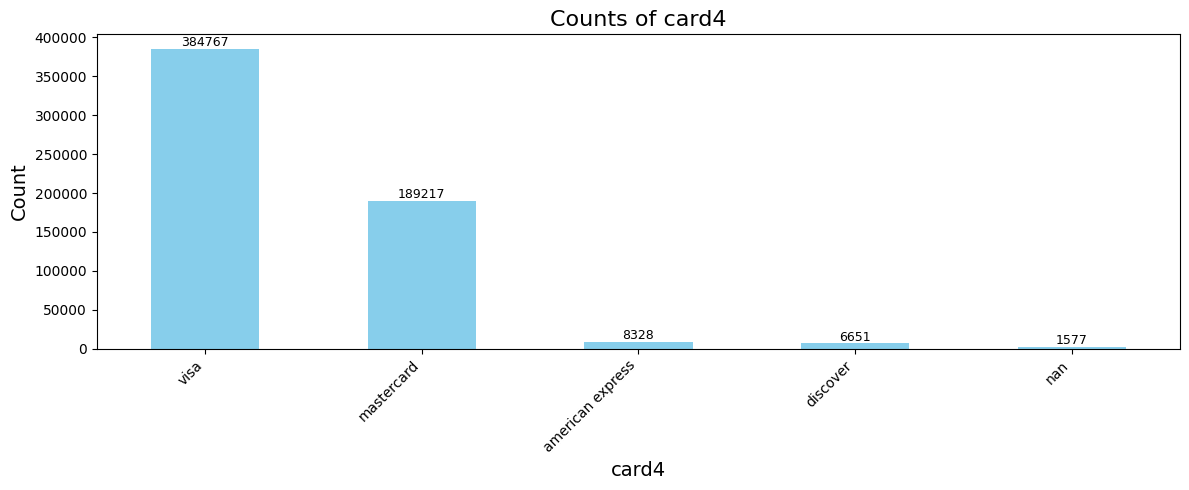

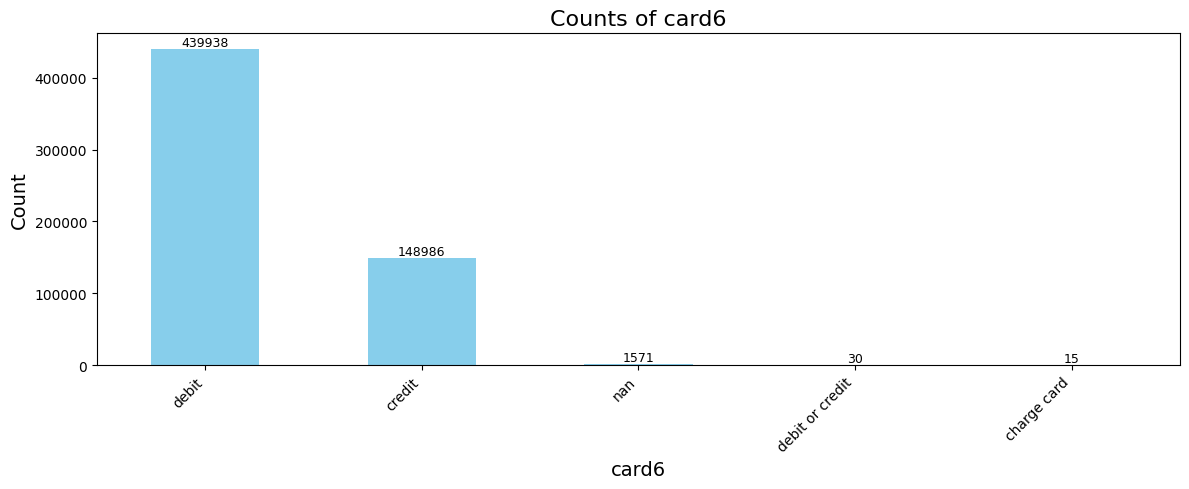

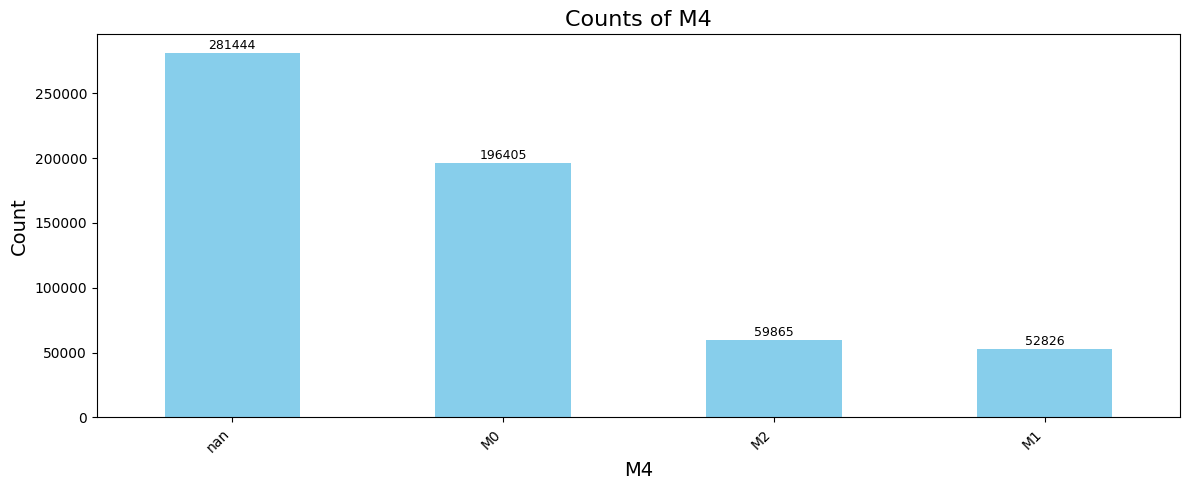

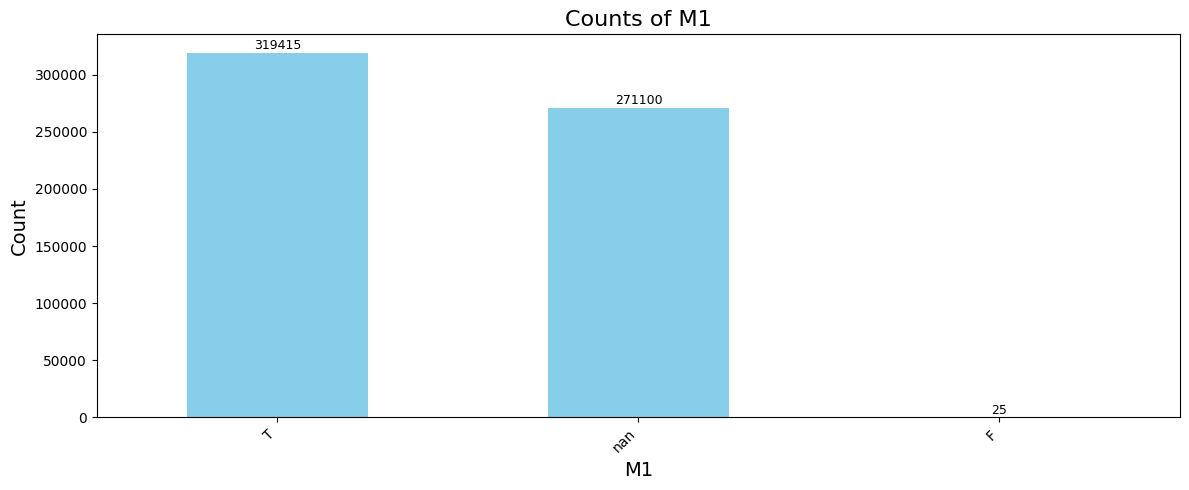

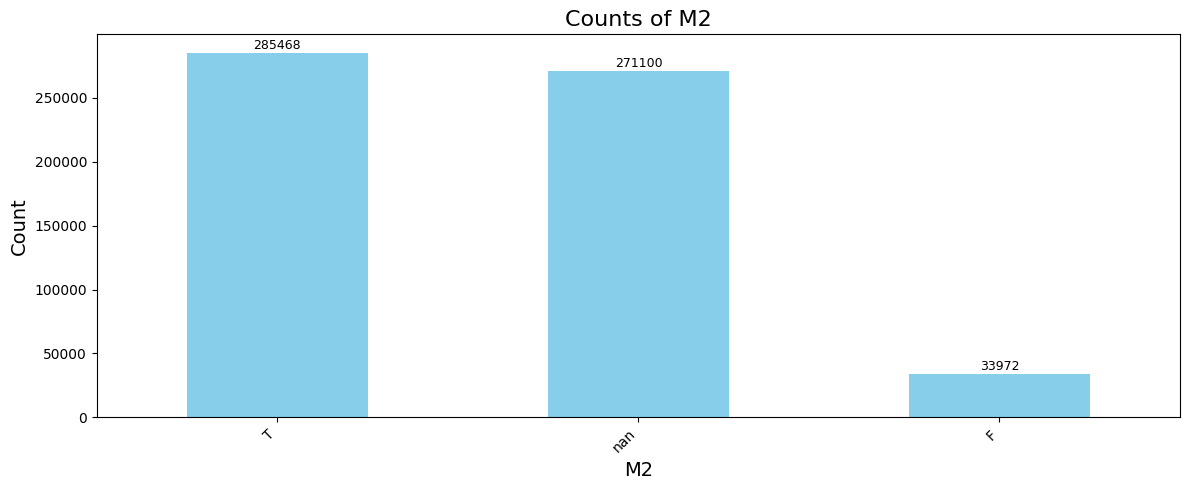

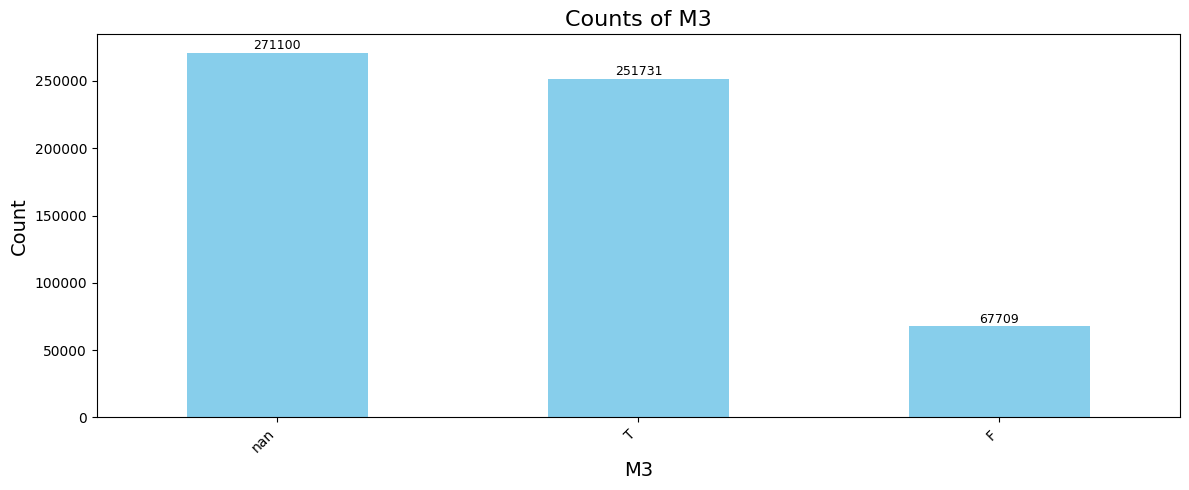

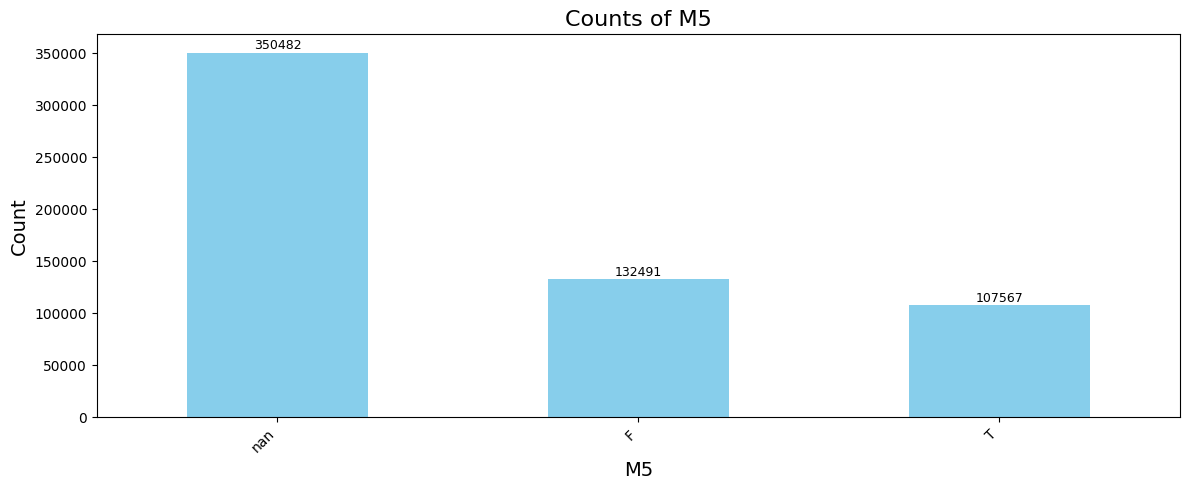

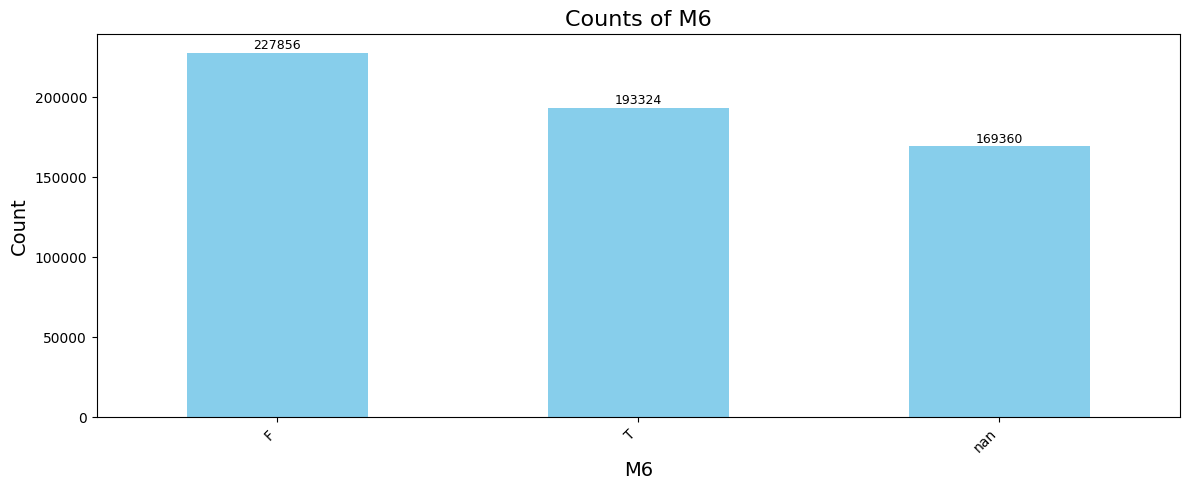

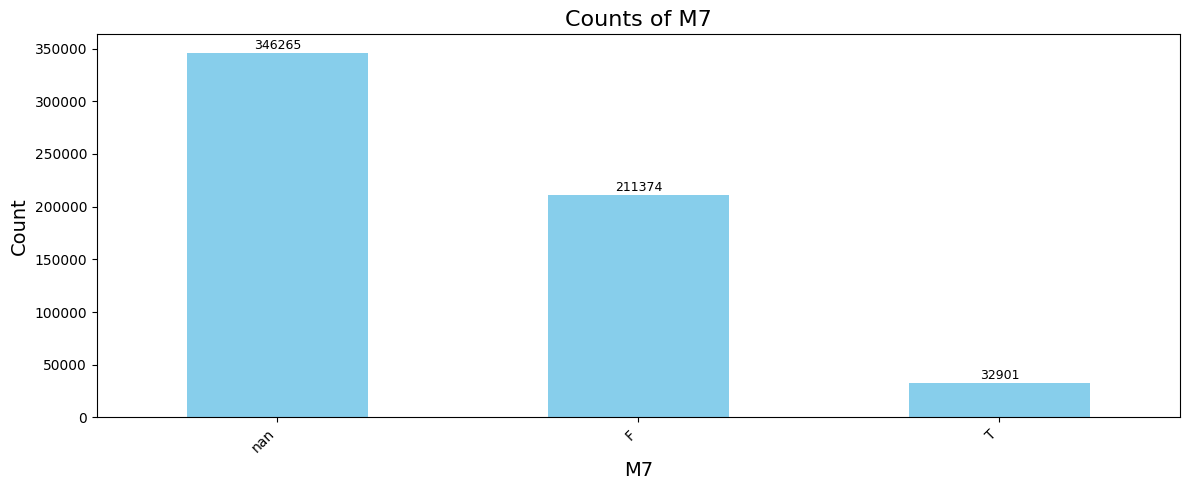

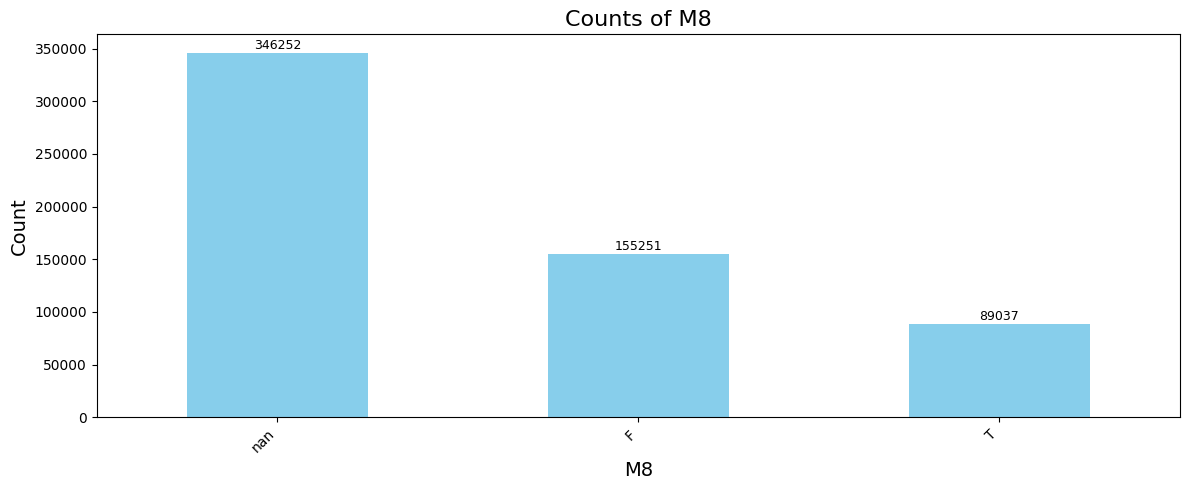

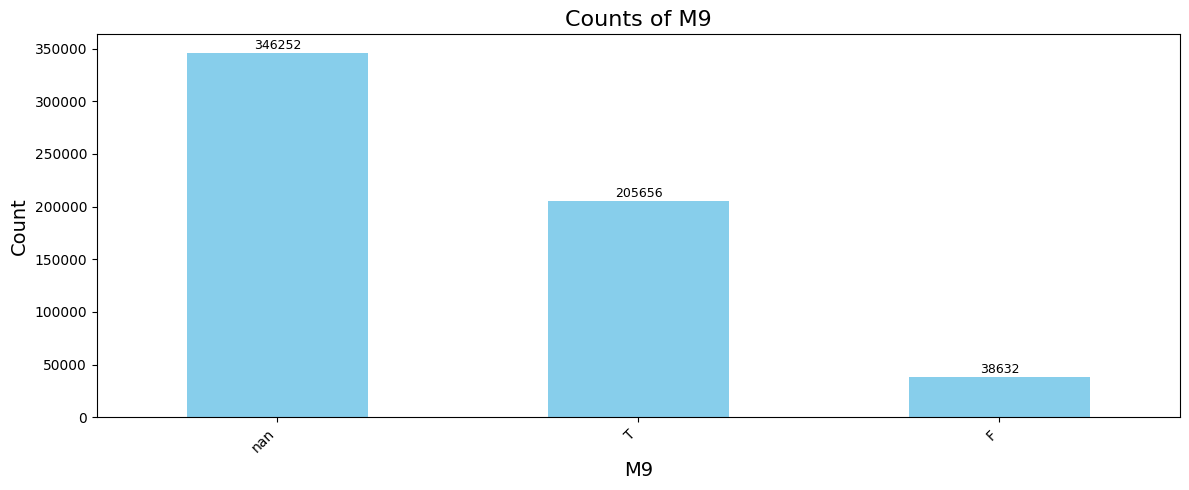

In [14]:
import matplotlib.pyplot as plt

def plot_value_counts(df, column, top=None):
    """
    Vẽ biểu đồ số lượng từng giá trị trong 1 column.
    df: DataFrame
    column: tên cột
    top: lấy top N giá trị nhiều nhất (None = lấy tất cả)
    """
    vc = df[column].value_counts(dropna=False)
    
    if top is not None:
        vc = vc.head(top)

    plt.figure(figsize=(12, 5))
    vc.plot(kind='bar', color='skyblue')
    
    plt.title(f'Counts of {column}', fontsize=16)
    plt.xlabel(column, fontsize=14)
    plt.ylabel("Count", fontsize=14)
    
    plt.xticks(rotation=45, ha='right')

    # Ghi số trên cột
    for i, v in enumerate(vc.values):
        plt.text(i, v + max(vc.values)*0.01, str(v), ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()


cols = [
    'ProductCD', 'card4', 'card6', 'M4',
    'M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9'
]

for col in cols:
    plot_value_counts(train, col)



#### Feature engineering

In [15]:
test.columns = test.columns.str.replace('-','_')


In [16]:
train['TransactionAmt_to_mean_card1'] = train['TransactionAmt'] / train.groupby(['card1'])['TransactionAmt'].transform('mean')
train['TransactionAmt_to_mean_card4'] = train['TransactionAmt'] / train.groupby(['card4'])['TransactionAmt'].transform('mean')
train['TransactionAmt_to_std_card1'] = train['TransactionAmt'] / train.groupby(['card1'])['TransactionAmt'].transform('std')
train['TransactionAmt_to_std_card4'] = train['TransactionAmt'] / train.groupby(['card4'])['TransactionAmt'].transform('std')

test['TransactionAmt_to_mean_card1'] = test['TransactionAmt'] / test.groupby(['card1'])['TransactionAmt'].transform('mean')
test['TransactionAmt_to_mean_card4'] = test['TransactionAmt'] / test.groupby(['card4'])['TransactionAmt'].transform('mean')
test['TransactionAmt_to_std_card1'] = test['TransactionAmt'] / test.groupby(['card1'])['TransactionAmt'].transform('std')
test['TransactionAmt_to_std_card4'] = test['TransactionAmt'] / test.groupby(['card4'])['TransactionAmt'].transform('std')

train['id_02_to_mean_card1'] = train['id_02'] / train.groupby(['card1'])['id_02'].transform('mean')
train['id_02_to_mean_card4'] = train['id_02'] / train.groupby(['card4'])['id_02'].transform('mean')
train['id_02_to_std_card1'] = train['id_02'] / train.groupby(['card1'])['id_02'].transform('std')
train['id_02_to_std_card4'] = train['id_02'] / train.groupby(['card4'])['id_02'].transform('std')

test['id_02_to_mean_card1'] = test['id_02'] / test.groupby(['card1'])['id_02'].transform('mean')
test['id_02_to_mean_card4'] = test['id_02'] / test.groupby(['card4'])['id_02'].transform('mean')
test['id_02_to_std_card1'] = test['id_02'] / test.groupby(['card1'])['id_02'].transform('std')
test['id_02_to_std_card4'] = test['id_02'] / test.groupby(['card4'])['id_02'].transform('std')

train['D15_to_mean_card1'] = train['D15'] / train.groupby(['card1'])['D15'].transform('mean')
train['D15_to_mean_card4'] = train['D15'] / train.groupby(['card4'])['D15'].transform('mean')
train['D15_to_std_card1'] = train['D15'] / train.groupby(['card1'])['D15'].transform('std')
train['D15_to_std_card4'] = train['D15'] / train.groupby(['card4'])['D15'].transform('std')

test['D15_to_mean_card1'] = test['D15'] / test.groupby(['card1'])['D15'].transform('mean')
test['D15_to_mean_card4'] = test['D15'] / test.groupby(['card4'])['D15'].transform('mean')
test['D15_to_std_card1'] = test['D15'] / test.groupby(['card1'])['D15'].transform('std')
test['D15_to_std_card4'] = test['D15'] / test.groupby(['card4'])['D15'].transform('std')

train['D15_to_mean_addr1'] = train['D15'] / train.groupby(['addr1'])['D15'].transform('mean')
train['D15_to_mean_addr2'] = train['D15'] / train.groupby(['addr2'])['D15'].transform('mean')
train['D15_to_std_addr1'] = train['D15'] / train.groupby(['addr1'])['D15'].transform('std')
train['D15_to_std_addr2'] = train['D15'] / train.groupby(['addr2'])['D15'].transform('std')

test['D15_to_mean_addr1'] = test['D15'] / test.groupby(['addr1'])['D15'].transform('mean')
test['D15_to_mean_addr2'] = test['D15'] / test.groupby(['addr2'])['D15'].transform('mean')
test['D15_to_std_addr1'] = test['D15'] / test.groupby(['addr1'])['D15'].transform('std')
test['D15_to_std_addr2'] = test['D15'] / test.groupby(['addr2'])['D15'].transform('std')
train[['P_emaildomain_1', 'P_emaildomain_2', 'P_emaildomain_3']] = train['P_emaildomain'].str.split('.', expand=True)
train[['R_emaildomain_1', 'R_emaildomain_2', 'R_emaildomain_3']] = train['R_emaildomain'].str.split('.', expand=True)
test[['P_emaildomain_1', 'P_emaildomain_2', 'P_emaildomain_3']] = test['P_emaildomain'].str.split('.', expand=True)
test[['R_emaildomain_1', 'R_emaildomain_2', 'R_emaildomain_3']] = test['R_emaildomain'].str.split('.', expand=True)


In [17]:
many_null_cols = [col for col in train.columns if train[col].isnull().sum() / train.shape[0] > 0.9]
many_null_cols_test = [col for col in test.columns if test[col].isnull().sum() / test.shape[0] > 0.9]

In [18]:
big_top_value_cols = [col for col in train.columns if train[col].value_counts(dropna=False, normalize=True).values[0] > 0.9]
big_top_value_cols_test = [col for col in test.columns if test[col].value_counts(dropna=False, normalize=True).values[0] > 0.9]

In [19]:
cols_to_drop = list(set(many_null_cols + many_null_cols_test + big_top_value_cols + big_top_value_cols_test + one_value_cols+ one_value_cols_test))
cols_to_drop.remove('isFraud')
len(cols_to_drop)


84

In [20]:
train = train.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)

In [21]:
from sklearn.preprocessing import LabelEncoder
cat_cols = ['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29',
            'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'ProductCD', 'card4', 'card6', 'M4','P_emaildomain',
            'R_emaildomain', 'card1', 'card2', 'card3',  'card5', 'addr1', 'addr2', 'M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9',
            'P_emaildomain_1', 'P_emaildomain_2', 'P_emaildomain_3', 'R_emaildomain_1', 'R_emaildomain_2', 'R_emaildomain_3']
for col in cat_cols:
    if col in train.columns:
        le = LabelEncoder()
        le.fit(list(train[col].astype(str).values) + list(test[col].astype(str).values))
        train[col] = le.transform(list(train[col].astype(str).values))
        test[col] = le.transform(list(test[col].astype(str).values))   

In [22]:
X = train.sort_values('TransactionDT').drop(['isFraud', 'TransactionDT', 'TransactionID'], axis=1)
y = train.sort_values('TransactionDT')['isFraud']
#X_test = test.sort_values('TransactionDT').drop(['TransactionDT', 'TransactionID'], axis=1)
X_test = test.drop(['TransactionDT', 'TransactionID'], axis=1)
del train
test = test[["TransactionDT", 'TransactionID']]


def clean_inf_nan(df):
    return df.replace([np.inf, -np.inf], np.nan)   

# Cleaning infinite values to NaN
X = clean_inf_nan(X)
X_test = clean_inf_nan(X_test )


In [23]:
gc.collect()

123

In [ ]:
# ==========================================
# IMPORT & CẤU HÌNH CHUNG
# ==========================================
import os
import numpy as np
import pandas as pd

import optuna
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Giới hạn các thư viện BLAS dùng 1 thread
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"

RANDOM_STATE = 42
N_SPLITS = 5

# ==========================================
# CHUẨN BỊ DỮ LIỆU
# ==========================================
# TODO: bạn tự load & tiền xử lý X, y ở đây
# - X: pandas DataFrame, shape (n_samples, n_features) ~ 168 cột
# - y: Series/array nhãn 0/1, phân phối khoảng 0:66%, 1:33%

# Ví dụ:
# df = pd.read_csv("your_data.csv")
# X = df.drop("target", axis=1)
# y = df["target"]

# Ở đây giả sử X, y đã tồn tại


# ==========================================
# HÀM CHỌN FEATURE BẰNG LIGHTGBM (SELECTOR)
# ==========================================
def select_top_features_lgb(X_tr, y_tr, n_top=80):
    """
    Train 1 model LightGBM trên tập train-fold,
    trả về tên top n_top feature quan trọng nhất.
    """
    selector = lgb.LGBMClassifier(
        n_estimators=100,
        num_leaves=64,
        max_depth=-1,
        learning_rate=0.5,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=1,
        random_state=RANDOM_STATE,
    )

    selector.fit(X_tr, y_tr)

    importances = selector.feature_importances_
    idx_sorted = np.argsort(importances)[::-1]
    top_idx = idx_sorted[:n_top]
    top_features = X_tr.columns[top_idx]
    return top_features


# ==========================================
# 1) LIGHTGBM – TUNING TRỰC TIẾP (KHÔNG OHE)
# ==========================================
def create_lgb_params(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": trial.suggest_categorical(
            "boosting_type", ["gbdt", "dart"]
        ),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),

        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),

        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.9),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),

        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),

        "n_estimators": trial.suggest_int("n_estimators", 300, 3000),

        # imbalance 0:66% – 1:33%
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.5, 2.5),

        "n_jobs": 1,
        "random_state": RANDOM_STATE,
    }
    return params


def objective_lgb(trial):
    params = create_lgb_params(trial)

    skf = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    oof_pred = np.zeros(len(X))
    oof_y = np.array(y)

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
        )

        prob_va = model.predict_proba(X_va)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(oof_y, oof_pred)
    return auc


# ==========================================
# 2) LOGISTIC REGRESSION + LGBM FEATURE SELECTOR
# ==========================================
def objective_logreg(trial):
    n_top = trial.suggest_int("n_top_features", 30, min(160, X.shape[1]))
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)

    skf = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    oof_pred = np.zeros(len(X))

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # 1) Chọn feature trên train-fold
        top_features = select_top_features_lgb(X_tr, y_tr, n_top=n_top)
        X_tr_sel = X_tr[top_features]
        X_va_sel = X_va[top_features]

        # 2) Pipeline scaler + logistic
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced",
                n_jobs=1
            ))
        ])

        pipe.fit(X_tr_sel, y_tr)
        prob_va = pipe.predict_proba(X_va_sel)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(y, oof_pred)
    return auc


# ==========================================
# 3) XGBOOST + LGBM FEATURE SELECTOR
# ==========================================
def objective_xgb(trial):
    n_top = trial.suggest_int("n_top_features", 30, min(160, X.shape[1]))

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.5, 2.5),
    }

    skf = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    oof_pred = np.zeros(len(X))

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        top_features = select_top_features_lgb(X_tr, y_tr, n_top=n_top)
        X_tr_sel = X_tr[top_features]
        X_va_sel = X_va[top_features]

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            nthread=1,
            use_label_encoder=False,
            **params,
        )

        model.fit(
            X_tr_sel, y_tr,
            eval_set=[(X_va_sel, y_va)],
            verbose=False,
        )

        prob_va = model.predict_proba(X_va_sel)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(y, oof_pred)
    return auc


# ==========================================
# 4) RANDOM FOREST + LGBM FEATURE SELECTOR
# ==========================================
def objective_rf(trial):
    n_top = trial.suggest_int("n_top_features", 30, min(160, X.shape[1]))

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }

    skf = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    oof_pred = np.zeros(len(X))

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        top_features = select_top_features_lgb(X_tr, y_tr, n_top=n_top)
        X_tr_sel = X_tr[top_features]
        X_va_sel = X_va[top_features]

        model = RandomForestClassifier(
            n_jobs=1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            **params,
        )

        model.fit(X_tr_sel, y_tr)
        prob_va = model.predict_proba(X_va_sel)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(y, oof_pred)
    return auc


# ==========================================
# CHẠY OPTUNA CHO 4 MODEL
# ==========================================
if __name__ == "__main__":
    # LightGBM
    study_lgb = optuna.create_study(
        direction="maximize", study_name="lgb_study"
    )
    
    study_lgb.optimize(objective_lgb, n_trials=3)
    print("=== LightGBM ===")
    print("Best AUC:", study_lgb.best_value)
    print("Best params:", study_lgb.best_params)
    print()

    # Logistic Regression
    study_logreg = optuna.create_study(
        direction="maximize", study_name="logreg_study"
    )
    study_logreg.optimize(objective_logreg, n_trials=3)
    print("=== Logistic Regression ===")
    print("Best AUC:", study_logreg.best_value)
    print("Best params:", study_logreg.best_params)
    print()

    # XGBoost
    study_xgb = optuna.create_study(
        direction="maximize", study_name="xgb_study"
    )
    study_xgb.optimize(objective_xgb, n_trials=3)
    print("=== XGBoost ===")
    print("Best AUC:", study_xgb.best_value)
    print("Best params:", study_xgb.best_params)
    print()

    # RandomForest
    study_rf = optuna.create_study(
        direction="maximize", study_name="rf_study"
    )
    study_rf.optimize(objective_rf, n_trials=3)
    print("=== RandomForest ===")
    print("Best AUC:", study_rf.best_value)
    print("Best params:", study_rf.best_params)
    print()

    # Bạn có thể so sánh 4 AUC và chọn model tốt nhất.


[I 2025-12-03 11:36:12,368] A new study created in memory with name: lgb_study


[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.583578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36362
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 369
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317038
[LightGBM] [Info] Start training from score -3.317038
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[W 2025-12-03 11:39:08,525] Trial 0 failed with parameters: {'boosting_type': 'dart', 'num_leaves': 60, 'max_depth': 3, 'learning_rate': 0.001264240234546503, 'min_child_samples': 49, 'subsample': 0.6815268627505484, 'subsample_freq': 7, 'colsample_bytree': 0.46134255467807195, 'reg_alpha': 0.0005393491673740039, 'reg_lambda': 0.004221895538426484, 'min_split_gain': 0.5321301638345837, 'n_estimators': 2768, 'scale_pos_weight': 2.280764569872885} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/envs/nlp_tutorial/lib/python3.9/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/ky/qkpfq2_s38z3403q_ltfrk680000gn/T/ipykernel_63143/617783912.py", line 123, in objective_lgb
    model.fit(
  File "/opt/anaconda3/envs/nlp_tutorial/lib/python3.9/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/opt/anaconda3/envs/nlp_tutorial/lib/python

KeyboardInterrupt: 

In [26]:
# ================== DATA ==================


def select_top_features_lgb(X_tr, y_tr, n_top=80):
    selector = lgb.LGBMClassifier(
        n_estimators=400,
        num_leaves=64,
        max_depth=-1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=1,
        random_state=RANDOM_STATE,
    )
    selector.fit(X_tr, y_tr)

    importances = selector.feature_importances_
    idx_sorted = np.argsort(importances)[::-1]
    top_idx = idx_sorted[:n_top]
    top_features = X_tr.columns[top_idx]
    return top_features

if __name__ == "__main__":
    n_top = 80
    top_features = select_top_features_lgb(X, y, n_top=n_top)
    print(f"Top {n_top} features:", list(top_features))

    import pickle
    with open("top_features.pkl", "wb") as f:
        pickle.dump(list(top_features), f)
    print("Đã lưu top_features.pkl")


[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.882919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36511
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 369
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076
Top 80 features: ['card1', 'card2', 'addr1', 'TransactionAmt_to_std_card1', 'C13', 'dist1', 'P_emaildomain', 'TransactionAmt', 'D2', 'TransactionAmt_to_mean_card1', 'D4', 'TransactionAmt_to_mean_card4', 'card5', 'TransactionAmt_to_std_card4', 'D1', 'C1', 'id_20', 'D10', 'D8', 'id_31', 'DeviceInfo', 'D15_to_mean_card1', 'C14', 'C2', 'C11', 'D15_to_mean_addr1', 'D15_to_std_card1', 'C6', 'D11', 'R_emaildomain', 'id_19', 'V313', 'C9', 'D1

In [28]:
# tune_models.py
import numpy as np
import optuna
import lightgbm as lgb
import pickle

from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# from data_config import load_data, get_folds, RANDOM_STATE, N_SPLITS

# ================== DATA ==================
# X, y, X_test = load_data()

# Giới hạn BLAS thread
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

RANDOM_STATE = 42
N_SPLITS = 5

# ========= CHỖ NÀY BẠN SỬA CHO PHÙ HỢP =========
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
TARGET_COL = "target"
# ==============================================

# def load_data():
#     """Đọc dữ liệu train/test, tách X, y, X_test"""
#     train = pd.read_csv(TRAIN_PATH)
#     test = pd.read_csv(TEST_PATH)

#     y = train[TARGET_COL]
#     X = train.drop(columns=[TARGET_COL])
#     X_test = test.copy()   # hoặc drop id nếu có

#     return X, y, X_test


def get_folds(y):
    """Tạo StratifiedKFold dùng chung"""
    folds = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    return folds

# ================== LOAD LIST FEATURE ĐÃ CHỌN ==================
# top_features.pkl được tạo ở bước feature selection trước đó
with open("top_features.pkl", "rb") as f:
    top_features = pickle.load(f)

print(f"Số feature được chọn: {len(top_features)}")
X_sel = X[top_features]   # dùng X_sel cho việc tune model
folds = get_folds(y)


# ================== 1) LIGHTGBM ==================
def create_lgb_params(trial):
    return {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "dart"]),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),  # giảm bớt để đỡ chậm
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.5, 2.5),
        "n_jobs": 1,
        "random_state": RANDOM_STATE,
    }


def objective_lgb(trial):
    params = create_lgb_params(trial)
    oof_pred = np.zeros(len(X_sel))
    oof_y = np.array(y)

    for tr_idx, va_idx in folds.split(X_sel, y):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
        )
        prob_va = model.predict_proba(X_va)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(oof_y, oof_pred)
    return auc


# ================== 2) LOGISTIC (KHÔNG SELECTOR NỮA) ==================
def objective_logreg(trial):
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)

    oof_pred = np.zeros(len(X_sel))

    for tr_idx, va_idx in folds.split(X_sel, y):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced",
                n_jobs=1
            ))
        ])
        pipe.fit(X_tr, y_tr)
        prob_va = pipe.predict_proba(X_va)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(y, oof_pred)
    return auc


# ================== 3) XGBOOST (DÙNG X_sel) ==================
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.5, 2.5),
    }

    oof_pred = np.zeros(len(X_sel))

    for tr_idx, va_idx in folds.split(X_sel, y):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            nthread=1,
            use_label_encoder=False,
            **params,
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False,
        )
        prob_va = model.predict_proba(X_va)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(y, oof_pred)
    return auc


# ================== 4) RANDOM FOREST (DÙNG X_sel) ==================
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }

    oof_pred = np.zeros(len(X_sel))

    for tr_idx, va_idx in folds.split(X_sel, y):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = RandomForestClassifier(
            n_jobs=1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            **params,
        )
        model.fit(X_tr, y_tr)
        prob_va = model.predict_proba(X_va)[:, 1]
        oof_pred[va_idx] = prob_va

    auc = roc_auc_score(y, oof_pred)
    return auc


# ================== MAIN ==================
if __name__ == "__main__":
    # Tùy máy yếu/mạnh mà bật từng cái:

    # ---- LightGBM ----
    study_lgb = optuna.create_study(direction="maximize", study_name="lgb_study")
    study_lgb.optimize(objective_lgb, n_trials=2)
    print("=== LightGBM ===")
    print("Best AUC:", study_lgb.best_value)
    print("Best params:", study_lgb.best_params)

    # ---- Logistic Regression ----
    # study_logreg = optuna.create_study(direction="maximize", study_name="logreg_study")
    # study_logreg.optimize(objective_logreg, n_trials=30)
    # print("=== Logistic Regression ===")
    # print("Best AUC:", study_logreg.best_value)
    # print("Best params:", study_logreg.best_params)

    # ---- XGBoost ----
    # study_xgb = optuna.create_study(direction="maximize", study_name="xgb_study")
    # study_xgb.optimize(objective_xgb, n_trials=30)
    # print("=== XGBoost ===")
    # print("Best AUC:", study_xgb.best_value)
    # print("Best params:", study_xgb.best_params)

    # ---- RandomForest ----
    # study_rf = optuna.create_study(direction="maximize", study_name="rf_study")
    # study_rf.optimize(objective_rf, n_trials=30)
    # print("=== RandomForest ===")
    # print("Best AUC:", study_rf.best_value)
    # print("Best params:", study_rf.best_params)


Số feature được chọn: 80


[I 2025-12-03 12:04:38,018] A new study created in memory with name: lgb_study


[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13829
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317038
[LightGBM] [Info] Start training from score -3.317038
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13837
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 80
[LightGBM] [

[W 2025-12-03 12:21:56,511] Trial 0 failed with parameters: {'boosting_type': 'dart', 'num_leaves': 20, 'max_depth': 8, 'learning_rate': 0.030497417061943047, 'min_child_samples': 47, 'subsample': 0.8319505611419391, 'subsample_freq': 7, 'colsample_bytree': 0.6615709921165596, 'reg_alpha': 0.1741448695016726, 'reg_lambda': 0.001724888132406283, 'min_split_gain': 0.017014860104151874, 'n_estimators': 671, 'scale_pos_weight': 1.750778568218323} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/envs/nlp_tutorial/lib/python3.9/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/ky/qkpfq2_s38z3403q_ltfrk680000gn/T/ipykernel_63143/495793834.py", line 99, in objective_lgb
    model.fit(
  File "/opt/anaconda3/envs/nlp_tutorial/lib/python3.9/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/opt/anaconda3/envs/nlp_tutorial/lib/python3.9/

KeyboardInterrupt: 

In [ ]:
import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit
n_fold = 5
folds = TimeSeriesSplit(n_splits=n_fold)
folds = KFold(n_splits=5)

In [ ]:
params = {'num_leaves': 256,
          'min_child_samples': 79,
          'objective': 'binary',
          'max_depth': 13,
          'learning_rate': 0.03,
          "boosting_type": "gbdt",
          "subsample_freq": 3,
          "subsample": 0.9,
          "bagging_seed": 11,
          "metric": 'auc',
          "verbosity": -1,
          'reg_alpha': 0.3,
          'reg_lambda': 0.3,
          'colsample_bytree': 0.9,
          #'categorical_feature': cat_cols
         }
result_dict_lgb = train_model_classification(X=X, X_test=X_test, y=y, params=params, folds=folds, model_type='lgb', eval_metric='auc', plot_feature_importance=True,  early_stopping_rounds=200, n_estimators=5000, averaging='usual', n_jobs=-1)

In [ ]:
result_dict_lgb = train_model_classification(
    X=X, 
    X_test=X_test, 
    y=y, 
    params=params, 
    folds=folds, 
    model_type='lgb', 
    eval_metric='auc', 
    plot_feature_importance=True,
    early_stopping_rounds=200, 
    n_estimators=10, 
    averaging='usual', 
    n_jobs=-1
)

In [ ]:
sub['isFraud'] = result_dict_lgb['prediction']
sub.to_csv('submission.csv', index=False)

In [ ]:
sub.head()

In [ ]:
pd.DataFrame(result_dict_lgb['oof']).to_csv('lgb_oof.csv', index=False)

In [ ]:
# # test = test.sort_values('TransactionDT')
# test['prediction'] = result_dict_lgb['prediction'] + result_dict_xgb['prediction']
# sub['isFraud'] = pd.merge(sub, test, on='TransactionID')['prediction']
# sub.to_csv('blend.csv', index=False)
test = test.sort_values('TransactionDT')
test['prediction'] = result_dict_xgb['prediction']
sub['isFraud'] = pd.merge(sub, test, on='TransactionID')['prediction']
sub.to_csv('submission_xgb.csv', index=False)